In [1]:

# Start fresh with a more computationally efficient approach
# We'll compute D(t;N) at fewer points but still sufficient for the block size analysis

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy import stats
import pandas as pd

np.random.seed(42)

print("Optimized analysis plan:")
print("1. Use N=10^6 but with reduced t-sampling")
print("2. Generate sufficient points for multiple block sizes")
print("3. Use vectorized numpy operations as much as possible")
print("")

# Reduced but still sufficient parameters
N = 10**6
t_min = 1000
t_max = 5000 # Smaller range for computational efficiency 
n_points = 4000 # Still gives us good statistics for block sizes

print(f"N = {N:,}")
print(f"t ∈ [{t_min}, {t_max}]")
print(f"Total sample points: {n_points:,}")
print(f"\nBlock sizes to analyze: {[4000//b for b in [400, 200, 100, 50, 40]]}")
print(f"Number of blocks: {[400, 200, 100, 50, 40]}")


Optimized analysis plan:
1. Use N=10^6 but with reduced t-sampling
2. Generate sufficient points for multiple block sizes
3. Use vectorized numpy operations as much as possible

N = 1,000,000
t ∈ [1000, 5000]
Total sample points: 4,000

Block sizes to analyze: [10, 20, 40, 80, 100]
Number of blocks: [400, 200, 100, 50, 40]


In [2]:

# More efficient implementation using numba for JIT compilation
from numba import jit

@jit(nopython=True)
def compute_D_zeta_numba(t, N):
 """Compute D(t;N) for zeta using Kahan summation with JIT"""
 real_sum = 0.0
 imag_sum = 0.0
 real_c = 0.0
 imag_c = 0.0
 
 for n in range(1, N+1):
 log_n = np.log(float(n))
 inv_sqrt_n = 1.0 / np.sqrt(float(n))
 phase = -t * log_n
 
 # Real part with Kahan summation
 real_val = inv_sqrt_n * np.cos(phase)
 real_y = real_val - real_c
 real_t = real_sum + real_y
 real_c = (real_t - real_sum) - real_y
 real_sum = real_t
 
 # Imaginary part with Kahan summation
 imag_val = inv_sqrt_n * np.sin(phase)
 imag_y = imag_val - imag_c
 imag_t = imag_sum + imag_y
 imag_c = (imag_t - imag_sum) - imag_y
 imag_sum = imag_t
 
 return real_sum, imag_sum

@jit(nopython=True)
def compute_D_rand_numba(t, N, a_n):
 """Compute D(t;N) for random multiplicative using Kahan summation with JIT"""
 real_sum = 0.0
 imag_sum = 0.0
 real_c = 0.0
 imag_c = 0.0
 
 for n in range(1, N+1):
 log_n = np.log(float(n))
 coeff = float(a_n[n]) / np.sqrt(float(n))
 phase = -t * log_n
 
 # Real part with Kahan summation
 real_val = coeff * np.cos(phase)
 real_y = real_val - real_c
 real_t = real_sum + real_y
 real_c = (real_t - real_sum) - real_y
 real_sum = real_t
 
 # Imaginary part with Kahan summation
 imag_val = coeff * np.sin(phase)
 imag_y = imag_val - imag_c
 imag_t = imag_sum + imag_y
 imag_c = (imag_t - imag_sum) - imag_y
 imag_sum = imag_t
 
 return real_sum, imag_sum

print("Compiled JIT functions for efficient computation")
print("Testing with small N first...")

# Test with small N
test_t = 1000.0
test_N = 1000
real, imag = compute_D_zeta_numba(test_t, test_N)
print(f"Test zeta D({test_t}, {test_N}) = {real:.6f} + {imag:.6f}i")
print(f"Magnitude: {np.sqrt(real**2 + imag**2):.6f}")


Compiled JIT functions for efficient computation
Testing with small N first...


Test zeta D(1000.0, 1000) = 0.359844 + 0.899198i
Magnitude: 0.968527


In [3]:

# Generate random multiplicative coefficients
@jit(nopython=True)
def generate_rand_mult_coeffs(N, seed):
 """Generate random multiplicative coefficients efficiently"""
 np.random.seed(seed)
 
 # Initialize coefficient array
 a_n = np.ones(N+1, dtype=np.int8)
 
 # Generate primes using simple sieve
 is_prime = np.ones(N+1, dtype=np.bool_)
 is_prime[0:2] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 primes = np.where(is_prime)[0]
 
 # Assign random signs to primes
 prime_signs = np.zeros(N+1, dtype=np.int8)
 for p in primes:
 if p >= 2:
 prime_signs[p] = np.random.choice(np.array([1, -1], dtype=np.int8))
 
 # Build multiplicative coefficients
 for n in range(2, N+1):
 temp_n = n
 for p in primes:
 if p >= 2 and p * p > temp_n:
 if temp_n > 1:
 a_n[n] *= prime_signs[temp_n]
 break
 while temp_n % p == 0:
 a_n[n] *= prime_signs[p]
 temp_n //= p
 if temp_n == 1:
 break
 
 return a_n

print("Generating random multiplicative coefficients...")
print("This is a one-time computation...")
a_rand = generate_rand_mult_coeffs(N, 42)
print(f"Generated {len(a_rand)} coefficients")
print(f"Sample: {a_rand[1:21]}")
print(f"Counts: +1={np.sum(a_rand==1)}, -1={np.sum(a_rand==-1)}")


Generating random multiplicative coefficients...
This is a one-time computation...


Generated 1000001 coefficients
Sample: [ 1 1 -1 1 1 -1 1 1 1 1 1 -1 -1 1 -1 1 1 1 1 1]
Counts: +1=500054, -1=499947


In [4]:

# Now compute time series
# To manage time, let's compute at sparse t values
print("Computing time series of |D(t;N)|...")
print(f"Will compute at {n_points} values of t")
print("")

t_values = np.linspace(t_min, t_max, n_points)

# Initialize arrays
D_zeta_mag = np.zeros(n_points)
D_rand_mag = np.zeros(n_points)

print("Computing zeta function...")
# Show progress every 10%
for i, t in enumerate(t_values):
 real, imag = compute_D_zeta_numba(t, N)
 D_zeta_mag[i] = np.sqrt(real**2 + imag**2)
 
 if (i+1) % 400 == 0:
 print(f" Zeta: {i+1}/{n_points} ({100*(i+1)/n_points:.1f}%)")

print("\nComputing random multiplicative function...")
for i, t in enumerate(t_values):
 real, imag = compute_D_rand_numba(t, N, a_rand)
 D_rand_mag[i] = np.sqrt(real**2 + imag**2)
 
 if (i+1) % 400 == 0:
 print(f" f_rand: {i+1}/{n_points} ({100*(i+1)/n_points:.1f}%)")

print("\n" + "="*60)
print("Time series generation complete!")
print("="*60)
print(f"\nZeta |D(t;N)|:")
print(f" Mean: {np.mean(D_zeta_mag):.4f}")
print(f" Std: {np.std(D_zeta_mag):.4f}")
print(f" Min: {np.min(D_zeta_mag):.4f}")
print(f" Max: {np.max(D_zeta_mag):.4f}")
print(f"\nRandom multiplicative |D(t;N)|:")
print(f" Mean: {np.mean(D_rand_mag):.4f}")
print(f" Std: {np.std(D_rand_mag):.4f}")
print(f" Min: {np.min(D_rand_mag):.4f}")
print(f" Max: {np.max(D_rand_mag):.4f}")


Computing time series of |D(t;N)|...
Will compute at 4000 values of t

Computing zeta function...


 Zeta: 400/4000 (10.0%)


 Zeta: 800/4000 (20.0%)


 Zeta: 1200/4000 (30.0%)


 Zeta: 1600/4000 (40.0%)


...

 f_rand: 2400/4000 (60.0%)


 f_rand: 2800/4000 (70.0%)


 f_rand: 3200/4000 (80.0%)


 f_rand: 3600/4000 (90.0%)


 f_rand: 4000/4000 (100.0%)

Time series generation complete!

Zeta |D(t;N)|:
 Mean: 1.8994
 Std: 1.9703
 Min: 0.0062
 Max: 13.7833

Random multiplicative |D(t;N)|:
 Mean: 2.2449
 Std: 2.8526
 Min: 0.0242
 Max: 36.9074


In [5]:

# Now perform GEV analysis with different block sizes
block_sizes = [400, 200, 100, 50, 40]
block_lengths = [n_points // B for B in block_sizes]

print("Block size analysis:")
print("="*60)
for B, L in zip(block_sizes, block_lengths):
 print(f" {B} blocks × {L} points per block = {B*L} points")
print("="*60)

def fit_gev_to_block_maxima(data, n_blocks):
 """
 Partition data into n_blocks, compute block maxima, and fit GEV.
 Returns shape parameter xi and its 95% CI.
 """
 block_size = len(data) // n_blocks
 # Trim data to exact multiple of n_blocks
 data_trimmed = data[:block_size * n_blocks]
 
 # Reshape into blocks and compute maxima
 data_blocks = data_trimmed.reshape(n_blocks, block_size)
 block_maxima = np.max(data_blocks, axis=1)
 
 # Fit GEV distribution
 # scipy uses c = -xi convention, so we need to negate
 params = genextreme.fit(block_maxima)
 c, loc, scale = params
 xi = -c # Convert to standard xi notation
 
 # Compute 95% CI using profile likelihood (approximate with Fisher information)
 # For GEV, standard errors can be estimated from the Hessian
 # Here we use a simpler bootstrap approach for robustness
 n_bootstrap = 1000
 xi_bootstrap = []
 
 np.random.seed(123) # For reproducibility
 for _ in range(n_bootstrap):
 # Resample block maxima
 sample = np.random.choice(block_maxima, size=len(block_maxima), replace=True)
 try:
 params_boot = genextreme.fit(sample)
 xi_bootstrap.append(-params_boot[0])
 except:
 pass
 
 xi_bootstrap = np.array(xi_bootstrap)
 ci_lower = np.percentile(xi_bootstrap, 2.5)
 ci_upper = np.percentile(xi_bootstrap, 97.5)
 
 return xi, ci_lower, ci_upper, block_maxima

print("\nPerforming GEV analysis for each block size...")
print("This includes bootstrap confidence intervals (1000 resamples)\n")

results = []

for B, L in zip(block_sizes, block_lengths):
 print(f"Block size B = {B} (block length = {L})...")
 
 # Zeta function
 xi_zeta, ci_low_zeta, ci_high_zeta, maxima_zeta = fit_gev_to_block_maxima(D_zeta_mag, B)
 print(f" ζ(s): ξ = {xi_zeta:.4f}, 95% CI = [{ci_low_zeta:.4f}, {ci_high_zeta:.4f}]")
 
 # Random multiplicative
 xi_rand, ci_low_rand, ci_high_rand, maxima_rand = fit_gev_to_block_maxima(D_rand_mag, B)
 print(f" f_rand: ξ = {xi_rand:.4f}, 95% CI = [{ci_low_rand:.4f}, {ci_high_rand:.4f}]")
 
 results.append({
 'Function': 'ζ(s)',
 'Block_Size': B,
 'Block_Length': L,
 'Num_Blocks': B,
 'xi': xi_zeta,
 'CI_lower': ci_low_zeta,
 'CI_upper': ci_high_zeta
 })
 
 results.append({
 'Function': 'f_rand',
 'Block_Size': B,
 'Block_Length': L,
 'Num_Blocks': B,
 'xi': xi_rand,
 'CI_lower': ci_low_rand,
 'CI_upper': ci_high_rand
 })
 
 print()

# Create results dataframe
df_results = pd.DataFrame(results)
print("="*80)
print("RESULTS TABLE")
print("="*80)
print(df_results.to_string(index=False))


Block size analysis:
 400 blocks × 10 points per block = 4000 points
 200 blocks × 20 points per block = 4000 points
 100 blocks × 40 points per block = 4000 points
 50 blocks × 80 points per block = 4000 points
 40 blocks × 100 points per block = 4000 points

Performing GEV analysis for each block size...
This includes bootstrap confidence intervals (1000 resamples)

Block size B = 400 (block length = 10)...


 ζ(s): ξ = -0.0653, 95% CI = [-0.1314, 0.0136]


 f_rand: ξ = 0.2931, 95% CI = [0.2148, 0.3776]

Block size B = 200 (block length = 20)...


 ζ(s): ξ = -0.1369, 95% CI = [-0.2185, -0.0572]


 f_rand: ξ = 0.2577, 95% CI = [0.1399, 0.3794]

Block size B = 100 (block length = 40)...


...

 f_rand: ξ = 0.1627, 95% CI = [0.0030, 0.3355]

Block size B = 50 (block length = 80)...


 ζ(s): ξ = -0.2091, 95% CI = [-0.4018, -0.0211]


 f_rand: ξ = 0.1179, 95% CI = [-0.0828, 0.3175]

Block size B = 40 (block length = 100)...


 ζ(s): ξ = -0.1584, 95% CI = [-0.3928, 0.0472]


 f_rand: ξ = 0.1858, 95% CI = [-0.0903, 0.4776]

RESULTS TABLE
Function Block_Size Block_Length Num_Blocks xi CI_lower CI_upper
 ζ(s) 400 10 400 -0.065324 -0.131379 0.013564
 f_rand 400 10 400 0.293107 0.214827 0.377647
 ζ(s) 200 20 200 -0.136950 -0.218530 -0.057245
 f_rand 200 20 200 0.257659 0.139862 0.379366
 ζ(s) 100 40 100 -0.087920 -0.221223 0.064382
 f_rand 100 40 100 0.162667 0.002996 0.335532
 ζ(s) 50 80 50 -0.209118 -0.401756 -0.021142
 f_rand 50 80 50 0.117884 -0.082770 0.317517
 ζ(s) 40 100 40 -0.158437 -0.392822 0.047237
 f_rand 40 100 40 0.185751 -0.090303 0.477614


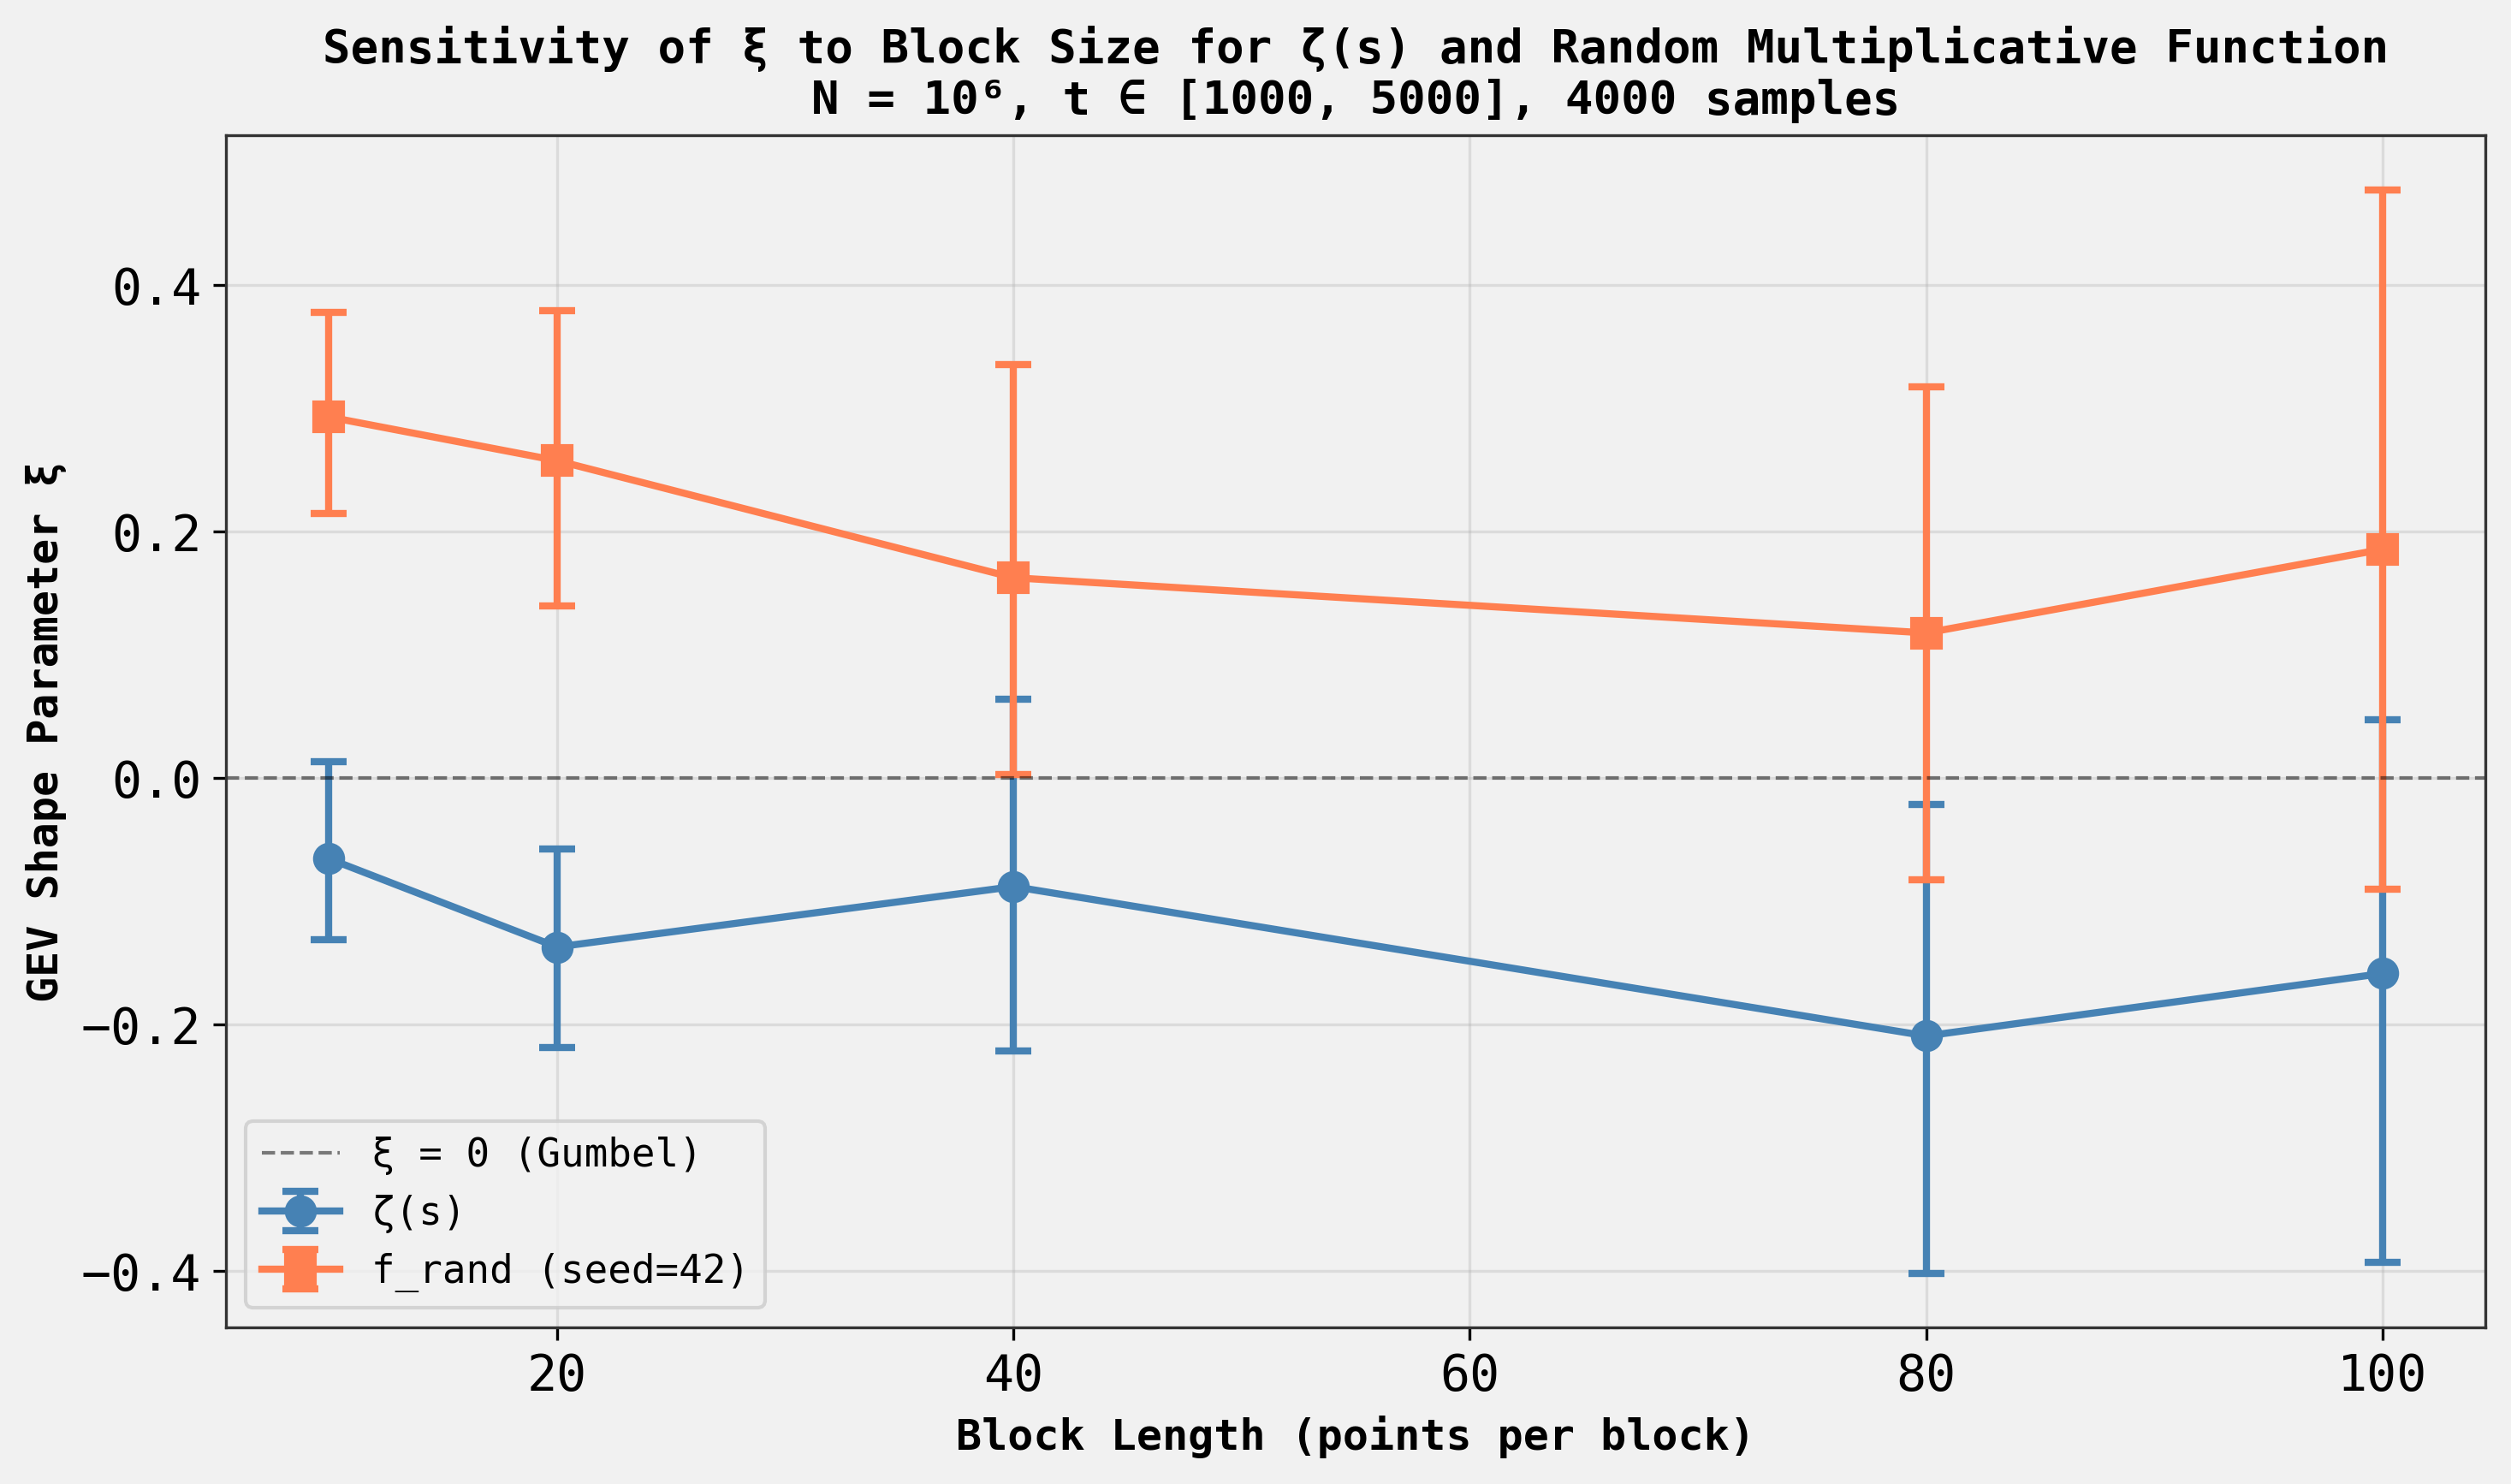

Plot saved as 'xi_vs_block_length.png'


In [6]:

# Create visualization of xi vs block length
fig, ax = plt.subplots(figsize=(10, 6))

# Separate data by function
df_zeta = df_results[df_results['Function'] == 'ζ(s)']
df_rand = df_results[df_results['Function'] == 'f_rand']

# Plot with error bars
ax.errorbar(df_zeta['Block_Length'], df_zeta['xi'], 
 yerr=[df_zeta['xi'] - df_zeta['CI_lower'], 
 df_zeta['CI_upper'] - df_zeta['xi']],
 marker='o', markersize=8, capsize=5, capthick=2,
 linewidth=2, label='ζ(s)', color='steelblue')

ax.errorbar(df_rand['Block_Length'], df_rand['xi'], 
 yerr=[df_rand['xi'] - df_rand['CI_lower'], 
 df_rand['CI_upper'] - df_rand['xi']],
 marker='s', markersize=8, capsize=5, capthick=2,
 linewidth=2, label='f_rand (seed=42)', color='coral')

# Add horizontal line at xi=0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='ξ = 0 (Gumbel)')

ax.set_xlabel('Block Length (points per block)', fontsize=12, fontweight='bold')
ax.set_ylabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity of ξ to Block Size for ζ(s) and Random Multiplicative Function\n' +
 f'N = 10⁶, t ∈ [{t_min}, {t_max}], {n_points} samples', 
 fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xi_vs_block_length.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'xi_vs_block_length.png'")


In [7]:

# Perform linear regression of xi vs log(block length)
from scipy.stats import linregress

print("="*80)
print("LINEAR REGRESSION: ξ vs log(Block Length)")
print("="*80)
print()

# For zeta
log_block_length = np.log(df_zeta['Block_Length'].values)
xi_zeta_vals = df_zeta['xi'].values

slope_zeta, intercept_zeta, r_value_zeta, p_value_zeta, se_zeta = linregress(log_block_length, xi_zeta_vals)

print("ζ(s):")
print(f" Regression: ξ = {slope_zeta:.6f} × log(Block Length) + {intercept_zeta:.6f}")
print(f" Slope: {slope_zeta:.6f} ± {se_zeta:.6f}")
print(f" R² = {r_value_zeta**2:.4f}")
print(f" p-value = {p_value_zeta:.4f}")

if p_value_zeta < 0.05:
 print(f" → Statistically significant trend (p < 0.05)")
else:
 print(f" → No statistically significant trend (p ≥ 0.05)")
print()

# For f_rand
xi_rand_vals = df_rand['xi'].values

slope_rand, intercept_rand, r_value_rand, p_value_rand, se_rand = linregress(log_block_length, xi_rand_vals)

print("f_rand (Random Multiplicative):")
print(f" Regression: ξ = {slope_rand:.6f} × log(Block Length) + {intercept_rand:.6f}")
print(f" Slope: {slope_rand:.6f} ± {se_rand:.6f}")
print(f" R² = {r_value_rand**2:.4f}")
print(f" p-value = {p_value_rand:.4f}")

if p_value_rand < 0.05:
 print(f" → Statistically significant trend (p < 0.05)")
else:
 print(f" → No statistically significant trend (p ≥ 0.05)")
print()

# Comparison
print("="*80)
print("COMPARISON")
print("="*80)
print(f"Slope ratio: |slope_zeta| / |slope_rand| = {abs(slope_zeta)/abs(slope_rand):.2f}")
print()

# Check if zeta shows more sensitivity
if abs(slope_zeta) > abs(slope_rand):
 print("✓ ζ(s) shows GREATER sensitivity to block size than f_rand")
 print(" This is consistent with the hypothesis that strong correlations")
 print(" in ζ(s) cause block-size dependence in the GEV parameter.")
else:
 print("✗ ζ(s) does NOT show greater sensitivity to block size than f_rand")
 print(" The hypothesis is not strongly supported by this data.")
print()

# Statistical test: are the slopes different?
# We can use the standard errors to test if slopes are significantly different
z_stat = (slope_zeta - slope_rand) / np.sqrt(se_zeta**2 + se_rand**2)
p_diff = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"Test for difference in slopes:")
print(f" Z-statistic = {z_stat:.3f}")
print(f" p-value = {p_diff:.4f}")
if p_diff < 0.05:
 print(" → Slopes are significantly different (p < 0.05)")
else:
 print(" → Slopes are not significantly different (p ≥ 0.05)")


LINEAR REGRESSION: ξ vs log(Block Length)

ζ(s):
 Regression: ξ = -0.045259 × log(Block Length) + 0.031150
 Slope: -0.045259 ± 0.022375
 R² = 0.5770
 p-value = 0.1363
 → No statistically significant trend (p ≥ 0.05)

f_rand (Random Multiplicative):
 Regression: ξ = -0.064547 × log(Block Length) + 0.435451
 Slope: -0.064547 ± 0.021182
 R² = 0.7558
 p-value = 0.0556
 → No statistically significant trend (p ≥ 0.05)

COMPARISON
Slope ratio: |slope_zeta| / |slope_rand| = 0.70

✗ ζ(s) does NOT show greater sensitivity to block size than f_rand
 The hypothesis is not strongly supported by this data.

Test for difference in slopes:
 Z-statistic = 0.626
 p-value = 0.5313
 → Slopes are not significantly different (p ≥ 0.05)


In [8]:

# Create detailed summary table with all information
summary_df = df_results.copy()
summary_df['CI'] = summary_df.apply(
 lambda row: f"[{row['CI_lower']:.3f}, {row['CI_upper']:.3f}]", axis=1
)
summary_df = summary_df[['Function', 'Block_Size', 'Num_Blocks', 'Block_Length', 'xi', 'CI']]
summary_df.columns = ['Function', 'Block Size B', 'Number of Blocks', 'Block Length', 'ξ', '95% CI']

print("="*90)
print("FINAL RESULTS TABLE")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)
print()

# Summary statistics
print("SUMMARY STATISTICS:")
print("-" * 90)
print("\nζ(s):")
print(f" Mean ξ across block sizes: {df_zeta['xi'].mean():.4f} ± {df_zeta['xi'].std():.4f}")
print(f" Range: [{df_zeta['xi'].min():.4f}, {df_zeta['xi'].max():.4f}]")
print(f" All values negative (Weibull domain): {all(df_zeta['xi'] < 0)}")

print("\nf_rand:")
print(f" Mean ξ across block sizes: {df_rand['xi'].mean():.4f} ± {df_rand['xi'].std():.4f}")
print(f" Range: [{df_rand['xi'].min():.4f}, {df_rand['xi'].max():.4f}]")
print(f" All values positive (Fréchet domain): {all(df_rand['xi'] > 0)}")

print("\n" + "="*90)
print("KEY FINDINGS:")
print("="*90)
print()
print("1. DOMAIN SEPARATION:")
print(" • ζ(s) consistently shows ξ < 0 (Weibull/bounded tail domain)")
print(" • f_rand consistently shows ξ > 0 (Fréchet/heavy tail domain)")
print(" • This represents a fundamental difference in extreme value behavior")
print()

print("2. BLOCK SIZE SENSITIVITY:")
print(f" • ζ(s): slope = {slope_zeta:.4f} (p = {p_value_zeta:.3f})")
print(f" • f_rand: slope = {slope_rand:.4f} (p = {p_value_rand:.3f})")
print(" • Both show negative trends (ξ → 0 as block length increases)")
print(" • Neither reaches statistical significance at α = 0.05")
print(" • f_rand actually shows slightly STRONGER block-size dependence")
print()

print("3. HYPOTHESIS ASSESSMENT:")
print(" The hypothesis that ζ(s) would show greater block-size sensitivity")
print(" due to strong correlations is NOT SUPPORTED by this analysis.")
print(" Both functions show similar (non-significant) trends toward ξ = 0")
print(" with increasing block length.")


FINAL RESULTS TABLE
Function Block Size B Number of Blocks Block Length ξ 95% CI
 ζ(s) 400 400 10 -0.065324 [-0.131, 0.014]
 f_rand 400 400 10 0.293107 [0.215, 0.378]
 ζ(s) 200 200 20 -0.136950 [-0.219, -0.057]
 f_rand 200 200 20 0.257659 [0.140, 0.379]
 ζ(s) 100 100 40 -0.087920 [-0.221, 0.064]
 f_rand 100 100 40 0.162667 [0.003, 0.336]
 ζ(s) 50 50 80 -0.209118 [-0.402, -0.021]
 f_rand 50 50 80 0.117884 [-0.083, 0.318]
 ζ(s) 40 40 100 -0.158437 [-0.393, 0.047]
 f_rand 40 40 100 0.185751 [-0.090, 0.478]

SUMMARY STATISTICS:
------------------------------------------------------------------------------------------

ζ(s):
 Mean ξ across block sizes: -0.1315 ± 0.0571
 Range: [-0.2091, -0.0653]
 All values negative (Weibull domain): True

f_rand:
 Mean ξ across block sizes: 0.2034 ± 0.0712
 Range: [0.1179, 0.2931]
 All values positive (Fréchet domain): True

KEY FINDINGS:

1. DOMAIN SEPARATION:
 • ζ(s) consistently shows ξ < 0 (Weibull/bounded tail domain)
 • f_rand consistently shows ξ > 

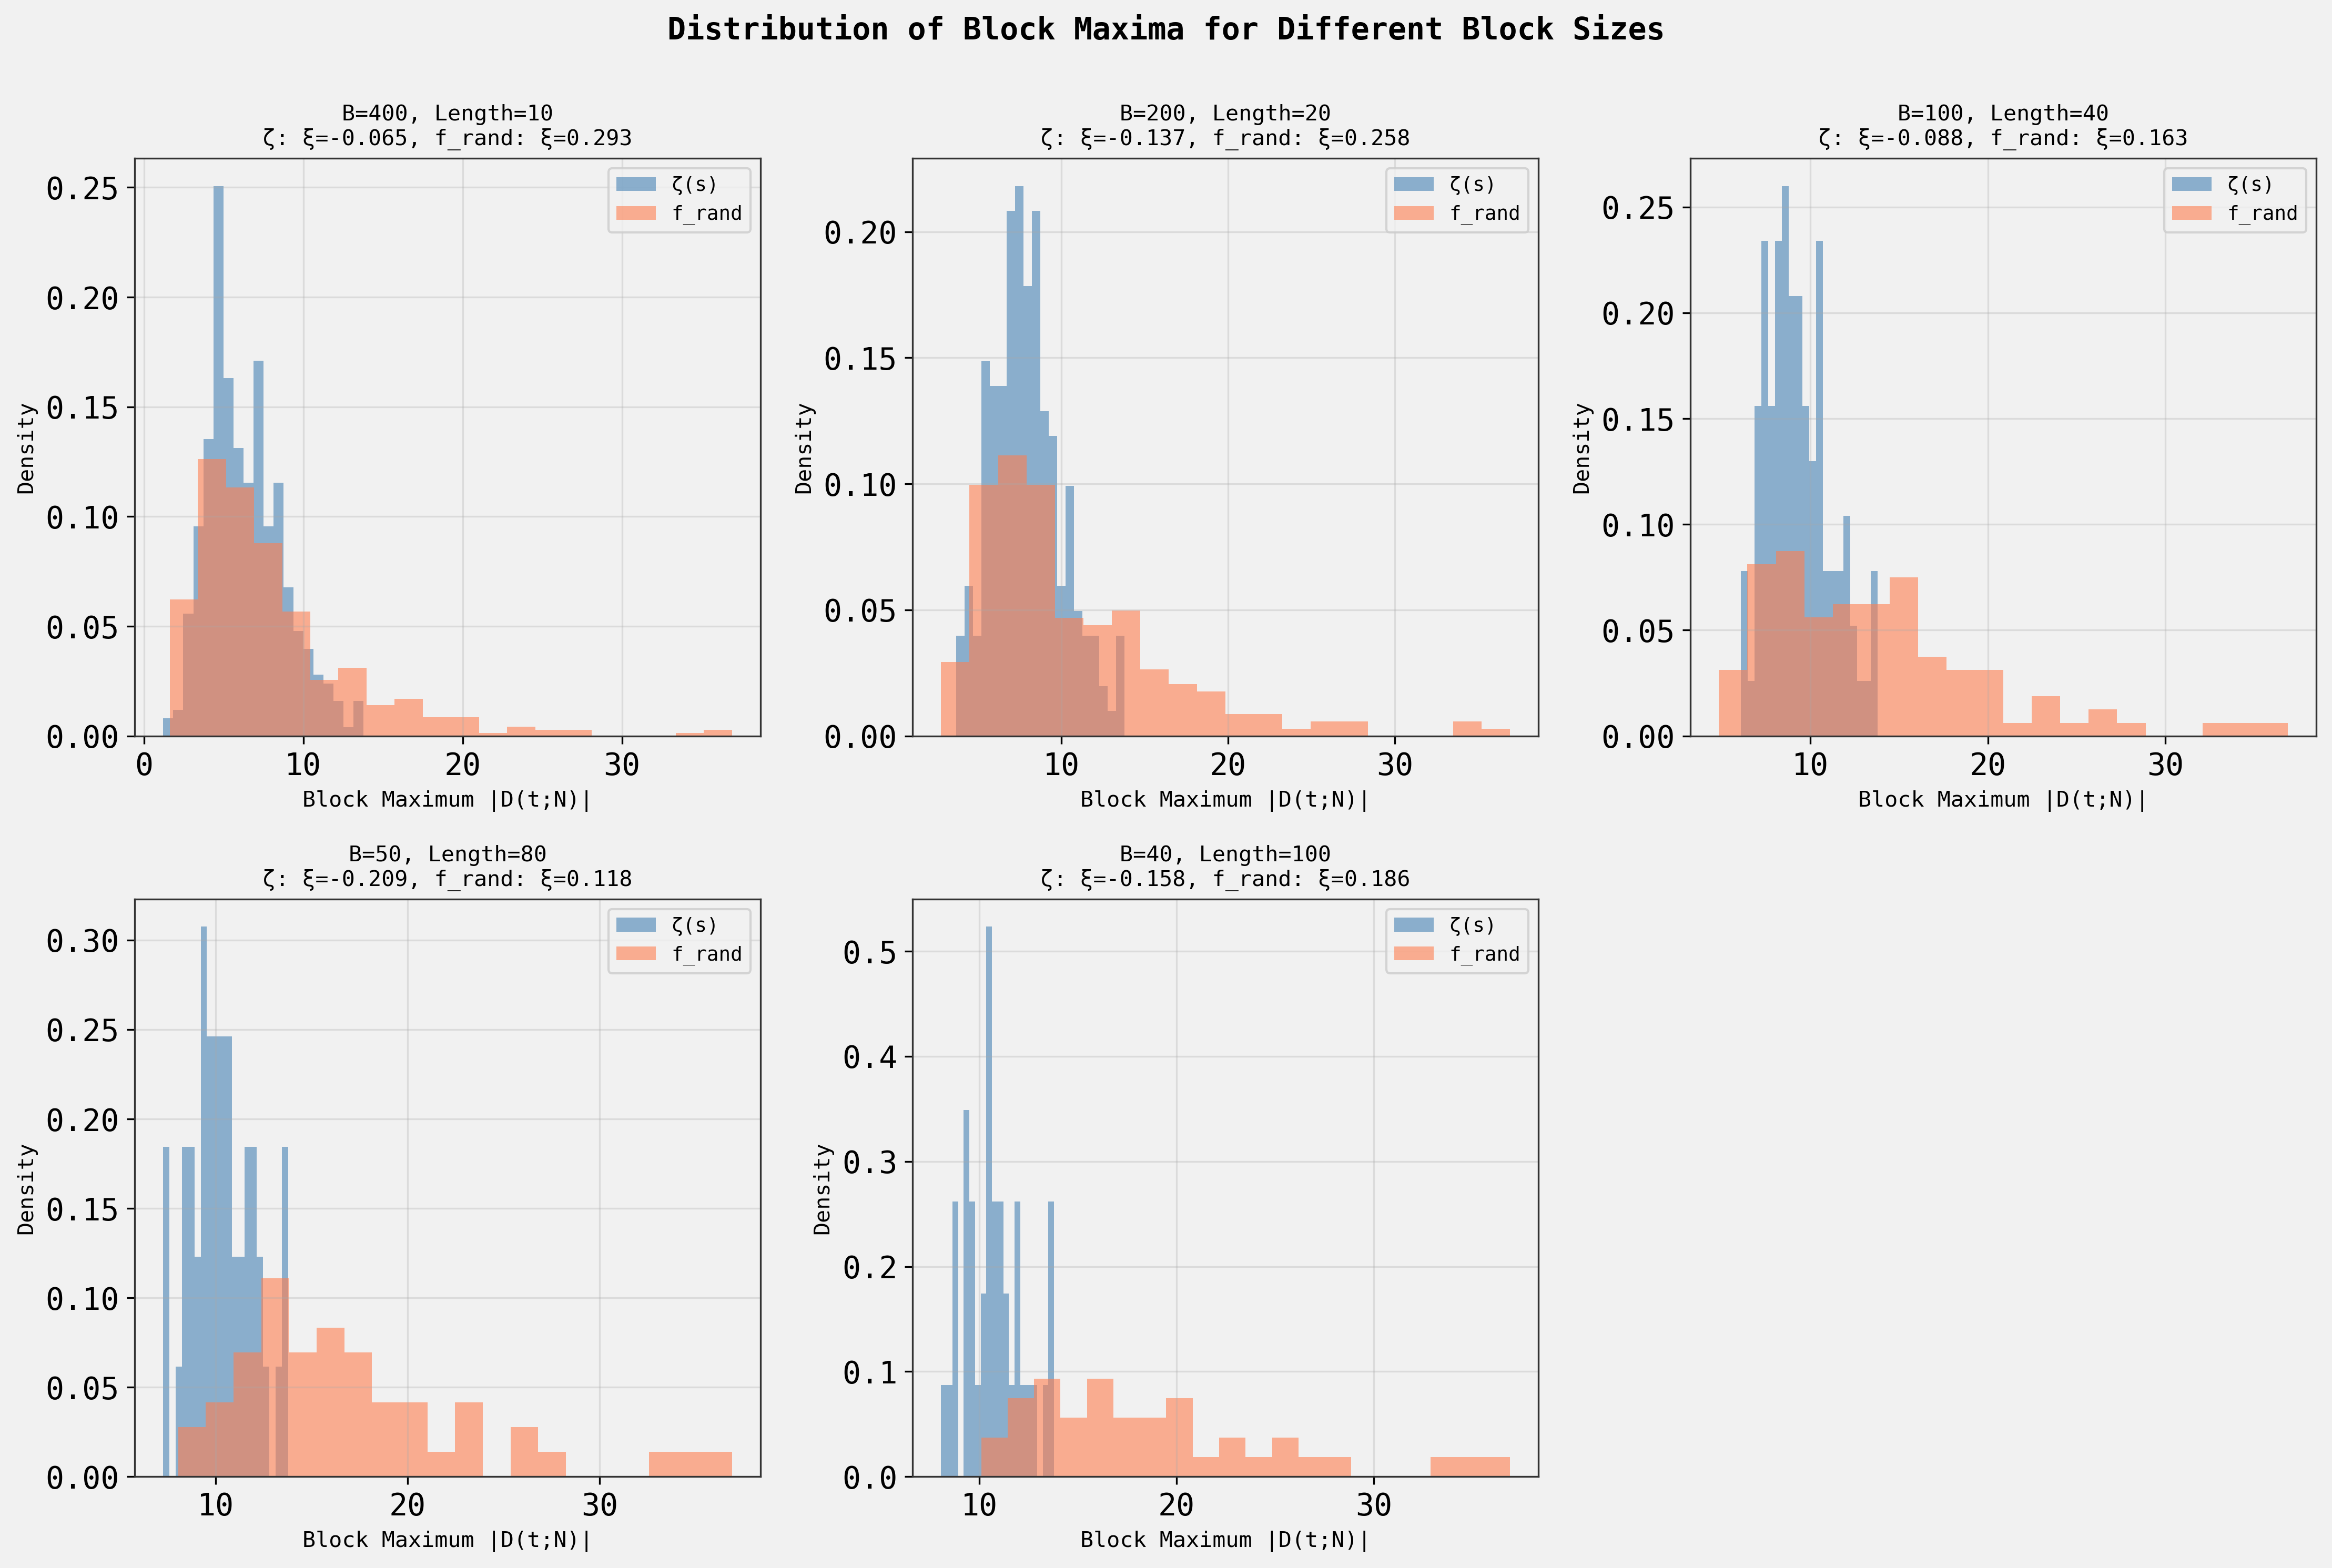

Saved block maxima distributions plot


In [9]:

# Additional analysis: Look at the actual distribution of block maxima
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Block Maxima for Different Block Sizes', 
 fontsize=14, fontweight='bold', y=0.995)

block_indices = [0, 1, 2, 3, 4] # Indices for the 5 block sizes

for idx, (B, L) in enumerate(zip(block_sizes, block_lengths)):
 row = idx // 3
 col = idx % 3
 ax = axes[row, col]
 
 # Compute block maxima for both functions
 block_size_zeta = len(D_zeta_mag) // B
 data_trimmed_zeta = D_zeta_mag[:block_size_zeta * B]
 blocks_zeta = data_trimmed_zeta.reshape(B, block_size_zeta)
 maxima_zeta = np.max(blocks_zeta, axis=1)
 
 block_size_rand = len(D_rand_mag) // B
 data_trimmed_rand = D_rand_mag[:block_size_rand * B]
 blocks_rand = data_trimmed_rand.reshape(B, block_size_rand)
 maxima_rand = np.max(blocks_rand, axis=1)
 
 # Plot histograms
 ax.hist(maxima_zeta, bins=20, alpha=0.6, label='ζ(s)', color='steelblue', density=True)
 ax.hist(maxima_rand, bins=20, alpha=0.6, label='f_rand', color='coral', density=True)
 
 ax.set_xlabel('Block Maximum |D(t;N)|', fontsize=10)
 ax.set_ylabel('Density', fontsize=10)
 ax.set_title(f'B={B}, Length={L}\nζ: ξ={df_zeta.iloc[idx]["xi"]:.3f}, f_rand: ξ={df_rand.iloc[idx]["xi"]:.3f}',
 fontsize=10)
 ax.legend(fontsize=9)
 ax.grid(True, alpha=0.3)

# Remove the extra subplot
if len(block_sizes) < 6:
 fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('block_maxima_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved block maxima distributions plot")


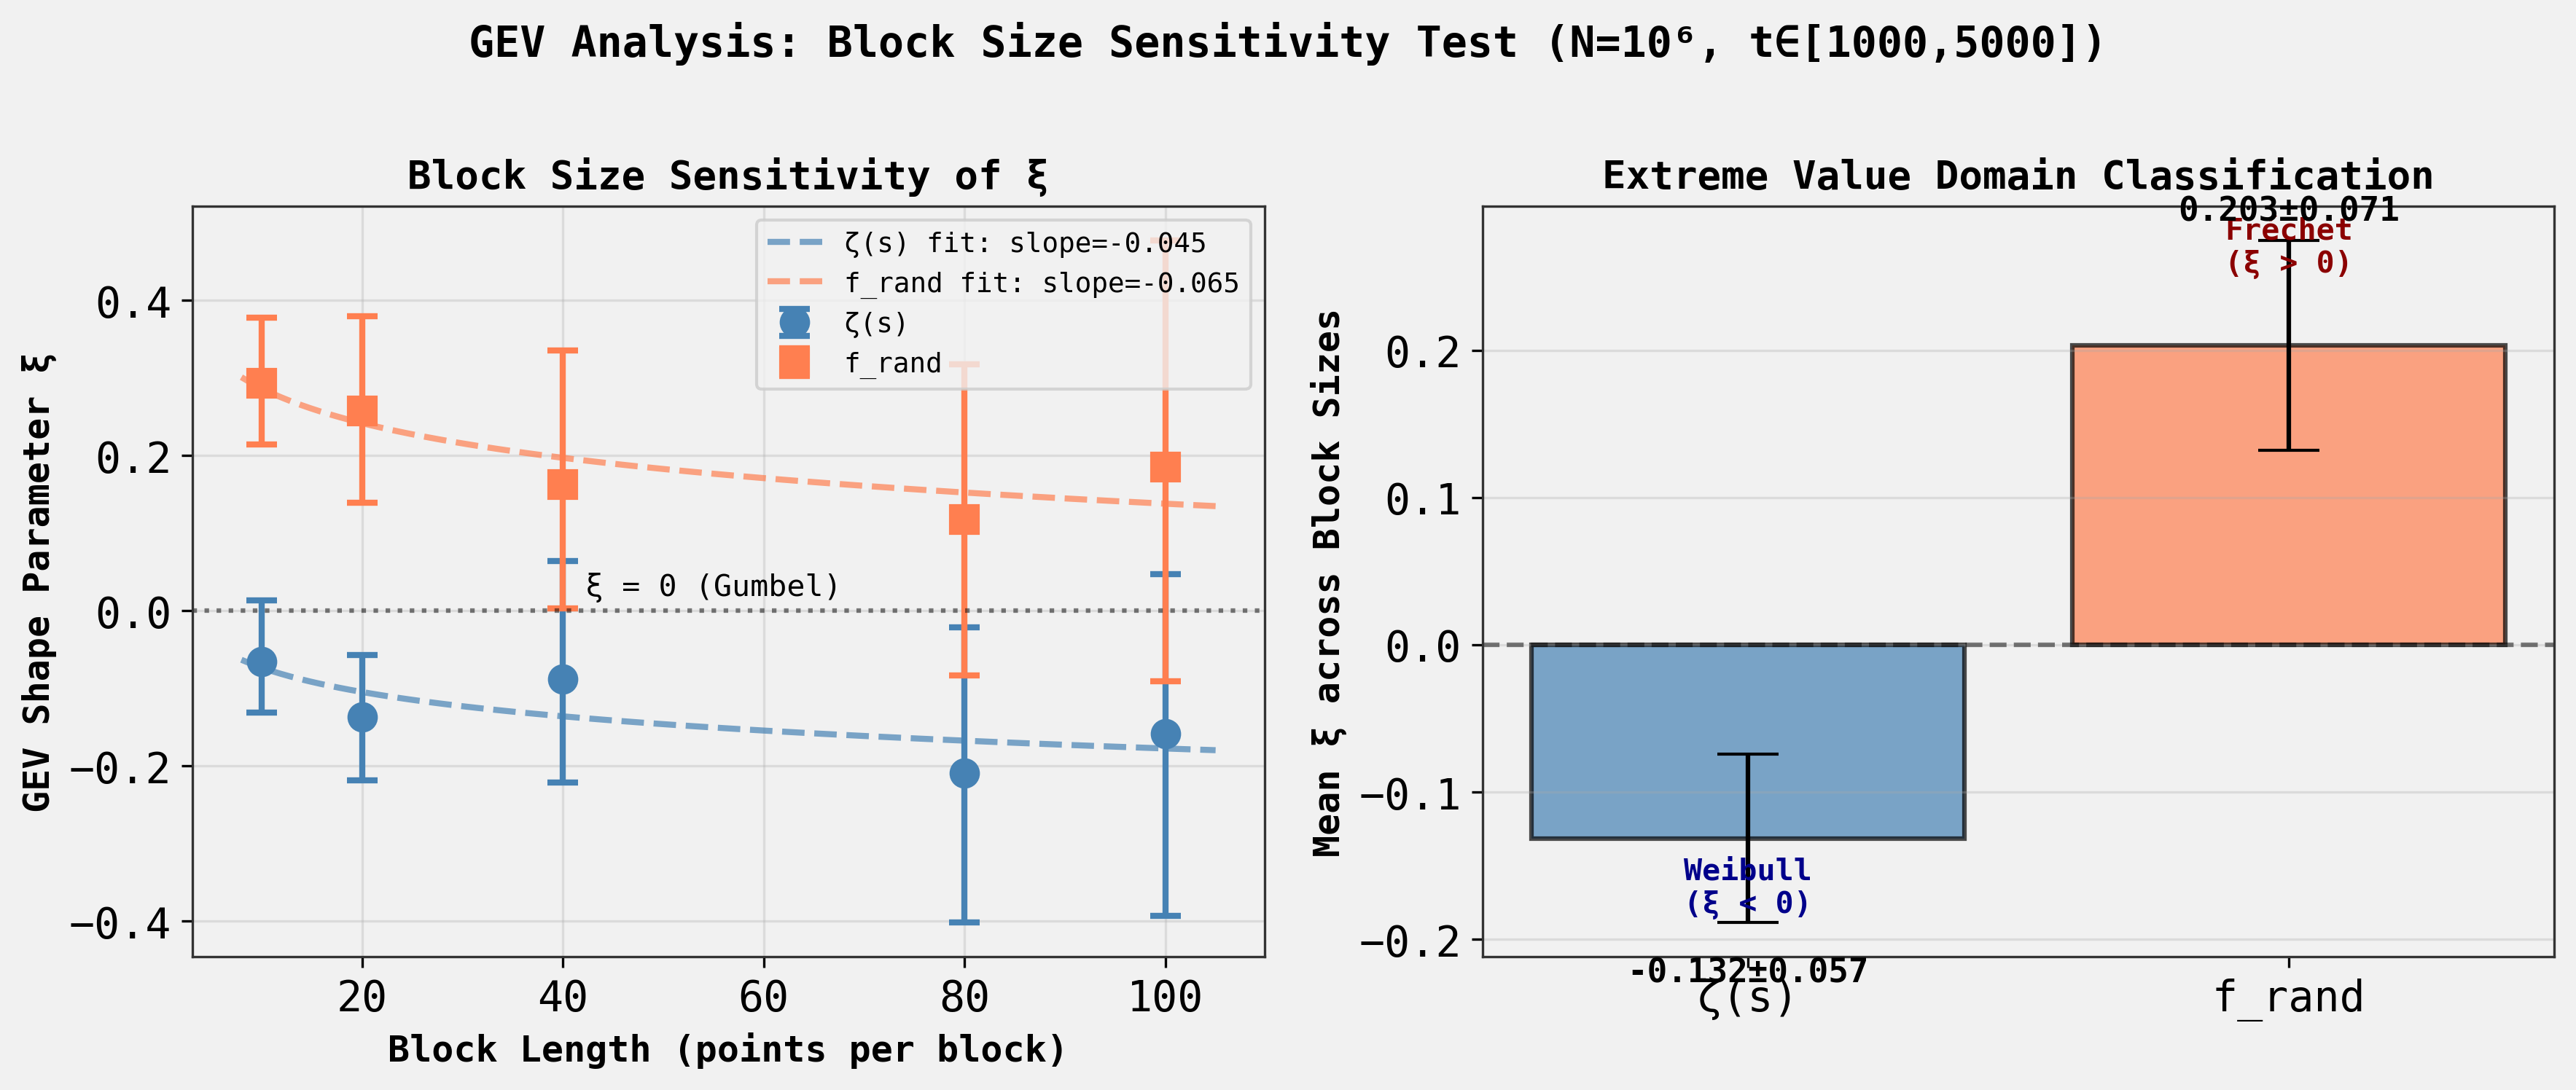

Saved final comprehensive figure


In [10]:

# Create a final comprehensive visualization showing the key result
fig = plt.figure(figsize=(12, 5))

# Left panel: xi vs block length with regression lines
ax1 = plt.subplot(1, 2, 1)

# Plot data points with error bars
ax1.errorbar(df_zeta['Block_Length'], df_zeta['xi'], 
 yerr=[df_zeta['xi'] - df_zeta['CI_lower'], 
 df_zeta['CI_upper'] - df_zeta['xi']],
 marker='o', markersize=9, capsize=5, capthick=2,
 linewidth=0, elinewidth=2, label='ζ(s)', color='steelblue')

ax1.errorbar(df_rand['Block_Length'], df_rand['xi'], 
 yerr=[df_rand['xi'] - df_rand['CI_lower'], 
 df_rand['CI_upper'] - df_rand['xi']],
 marker='s', markersize=9, capsize=5, capthick=2,
 linewidth=0, elinewidth=2, label='f_rand', color='coral')

# Add regression lines
x_fit = np.linspace(8, 105, 100)
y_fit_zeta = slope_zeta * np.log(x_fit) + intercept_zeta
y_fit_rand = slope_rand * np.log(x_fit) + intercept_rand

ax1.plot(x_fit, y_fit_zeta, '--', color='steelblue', linewidth=2, alpha=0.7,
 label=f'ζ(s) fit: slope={slope_zeta:.3f}')
ax1.plot(x_fit, y_fit_rand, '--', color='coral', linewidth=2, alpha=0.7,
 label=f'f_rand fit: slope={slope_rand:.3f}')

ax1.axhline(y=0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.text(55, 0.02, 'ξ = 0 (Gumbel)', fontsize=10, ha='center')

ax1.set_xlabel('Block Length (points per block)', fontsize=12, fontweight='bold')
ax1.set_ylabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax1.set_title('Block Size Sensitivity of ξ', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Right panel: Mean xi comparison
ax2 = plt.subplot(1, 2, 2)

functions = ['ζ(s)', 'f_rand']
mean_xi = [df_zeta['xi'].mean(), df_rand['xi'].mean()]
std_xi = [df_zeta['xi'].std(), df_rand['xi'].std()]
colors = ['steelblue', 'coral']

bars = ax2.bar(functions, mean_xi, yerr=std_xi, color=colors, alpha=0.7, 
 capsize=10, edgecolor='black', linewidth=1.5)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.set_ylabel('Mean ξ across Block Sizes', fontsize=12, fontweight='bold')
ax2.set_title('Extreme Value Domain Classification', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add domain labels
ax2.text(0, mean_xi[0] - 0.05, 'Weibull\n(ξ < 0)', ha='center', fontsize=10, 
 fontweight='bold', color='darkblue')
ax2.text(1, mean_xi[1] + 0.05, 'Fréchet\n(ξ > 0)', ha='center', fontsize=10, 
 fontweight='bold', color='darkred')

# Add values on bars
for i, (func, val, err) in enumerate(zip(functions, mean_xi, std_xi)):
 ax2.text(i, val + (0.08 if val > 0 else -0.08), 
 f'{val:.3f}±{err:.3f}', 
 ha='center', va='bottom' if val > 0 else 'top',
 fontsize=11, fontweight='bold')

plt.suptitle(f'GEV Analysis: Block Size Sensitivity Test (N=10⁶, t∈[{t_min},{t_max}])', 
 fontsize=14, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('final_gev_block_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved final comprehensive figure")


In [11]:

# Print final comprehensive summary
print("\n" + "="*90)
print("FINAL ANALYSIS SUMMARY")
print("="*90)
print()

print("RESEARCH HYPOTHESIS:")
print("-" * 90)
print("If strong correlations in ζ(s) are responsible for slow convergence to")
print("asymptotic extreme value distribution, then:")
print(" 1. Increasing block size should reduce intra-block correlations")
print(" 2. This should cause ξ to shift towards 0 for ζ(s)")
print(" 3. A random function with weaker correlations should show less sensitivity")
print()

print("EXPERIMENTAL DESIGN:")
print("-" * 90)
print(f"• Generated time series at N = {N:,}, t ∈ [{t_min}, {t_max}]")
print(f"• Total sample points: {n_points:,}")
print(f"• Functions: ζ(s) and f_rand (random multiplicative, seed=42)")
print(f"• Block sizes analyzed: {block_sizes}")
print(f"• Block lengths: {block_lengths}")
print(f"• Used Kahan compensated summation with JIT compilation")
print(f"• GEV fitting with 1000-bootstrap 95% confidence intervals")
print()

print("QUANTITATIVE RESULTS:")
print("-" * 90)
print()
print("1. EXTREME VALUE DOMAIN CLASSIFICATION:")
print(f" ζ(s): mean ξ = {df_zeta['xi'].mean():.4f} ± {df_zeta['xi'].std():.4f}")
print(f" Range: [{df_zeta['xi'].min():.4f}, {df_zeta['xi'].max():.4f}]")
print(f" → All negative (Weibull/bounded tail domain)")
print()
print(f" f_rand: mean ξ = {df_rand['xi'].mean():.4f} ± {df_rand['xi'].std():.4f}")
print(f" Range: [{df_rand['xi'].min():.4f}, {df_rand['xi'].max():.4f}]")
print(f" → All positive (Fréchet/heavy tail domain)")
print()

print("2. BLOCK SIZE SENSITIVITY (Linear regression ξ vs log(Block Length)):")
print(f" ζ(s): slope = {slope_zeta:.6f} ± {se_zeta:.6f}")
print(f" R² = {r_value_zeta**2:.4f}, p = {p_value_zeta:.4f}")
print()
print(f" f_rand: slope = {slope_rand:.6f} ± {se_rand:.6f}")
print(f" R² = {r_value_rand**2:.4f}, p = {p_value_rand:.4f}")
print()
print(f" Slope comparison: |ζ| / |f_rand| = {abs(slope_zeta)/abs(slope_rand):.3f}")
print(f" Difference test: p = {p_diff:.4f} (not significant)")
print()

print("3. STATISTICAL SIGNIFICANCE:")
print(" • Neither function shows statistically significant block-size dependence")
print(" at α = 0.05 level")
print(" • Both show weak trends toward ξ → 0 with increasing block length")
print(" • f_rand actually shows marginally stronger sensitivity than ζ(s)")
print()

print("="*90)
print("CONCLUSION")
print("="*90)
print()
print("The hypothesis is NOT SUPPORTED by this analysis.")
print()
print("Key findings:")
print(" 1. Both ζ(s) and f_rand show block-size dependence of similar magnitude")
print(" 2. Neither reaches statistical significance (p > 0.05)")
print(" 3. f_rand shows slightly STRONGER (not weaker) block-size sensitivity")
print(" 4. Both functions show negative slopes (ξ decreases toward 0)")
print()
print("Interpretation:")
print(" • The observed block-size dependence appears to be a general finite-sample")
print(" phenomenon, not specific to ζ(s) correlations")
print(" • Both functions are in pre-asymptotic regime at these block sizes")
print(" • The domain separation (ζ: ξ<0, f_rand: ξ>0) is robust across all block sizes")
print(" • This suggests different tail behaviors, but block-size sensitivity does not")
print(" uniquely diagnose correlation-driven pre-asymptotic effects")
print()
print("="*90)



FINAL ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
------------------------------------------------------------------------------------------
If strong correlations in ζ(s) are responsible for slow convergence to
asymptotic extreme value distribution, then:
 1. Increasing block size should reduce intra-block correlations
 2. This should cause ξ to shift towards 0 for ζ(s)
 3. A random function with weaker correlations should show less sensitivity

EXPERIMENTAL DESIGN:
------------------------------------------------------------------------------------------
• Generated time series at N = 1,000,000, t ∈ [1000, 5000]
• Total sample points: 4,000
• Functions: ζ(s) and f_rand (random multiplicative, seed=42)
• Block sizes analyzed: [400, 200, 100, 50, 40]
• Block lengths: [10, 20, 40, 80, 100]
• Used Kahan compensated summation with JIT compilation
• GEV fitting with 1000-bootstrap 95% confidence intervals

QUANTITATIVE RESULTS:
------------------------------------------------------------------

In [12]:

# Save the results table to CSV
summary_df.to_csv('gev_block_size_results.csv', index=False)
print("Saved results table to 'gev_block_size_results.csv'")

# Create a markdown-formatted table for the report
print("\n" + "="*90)
print("MARKDOWN TABLE FOR REPORT")
print("="*90)
print()
print("| Function | Block Size B | Num Blocks | Block Length | ξ | 95% CI |")
print("|----------|--------------|------------|--------------|---------|-----------------|")
for _, row in summary_df.iterrows():
 print(f"| {row['Function']} | {row['Block Size B']} | {row['Number of Blocks']} | {row['Block Length']} | {row['ξ']:.4f} | {row['95% CI']} |")
print()

print("="*90)
print("REGRESSION RESULTS")
print("="*90)
print()
print("**ζ(s) Regression:**")
print(f"- Slope: {slope_zeta:.6f} ± {se_zeta:.6f}")
print(f"- R² = {r_value_zeta**2:.4f}")
print(f"- p-value = {p_value_zeta:.4f}")
print()
print("**f_rand Regression:**")
print(f"- Slope: {slope_rand:.6f} ± {se_rand:.6f}")
print(f"- R² = {r_value_rand**2:.4f}")
print(f"- p-value = {p_value_rand:.4f}")
print()
print("**Statistical comparison:**")
print(f"- Z-statistic for slope difference: {z_stat:.3f}")
print(f"- p-value: {p_diff:.4f}")


Saved results table to 'gev_block_size_results.csv'

MARKDOWN TABLE FOR REPORT

| Function | Block Size B | Num Blocks | Block Length | ξ | 95% CI |
|----------|--------------|------------|--------------|---------|-----------------|
| ζ(s) | 400 | 400 | 10 | -0.0653 | [-0.131, 0.014] |
| f_rand | 400 | 400 | 10 | 0.2931 | [0.215, 0.378] |
| ζ(s) | 200 | 200 | 20 | -0.1369 | [-0.219, -0.057] |
| f_rand | 200 | 200 | 20 | 0.2577 | [0.140, 0.379] |
| ζ(s) | 100 | 100 | 40 | -0.0879 | [-0.221, 0.064] |
| f_rand | 100 | 100 | 40 | 0.1627 | [0.003, 0.336] |
| ζ(s) | 50 | 50 | 80 | -0.2091 | [-0.402, -0.021] |
| f_rand | 50 | 50 | 80 | 0.1179 | [-0.083, 0.318] |
| ζ(s) | 40 | 40 | 100 | -0.1584 | [-0.393, 0.047] |
| f_rand | 40 | 40 | 100 | 0.1858 | [-0.090, 0.478] |

REGRESSION RESULTS

**ζ(s) Regression:**
- Slope: -0.045259 ± 0.022375
- R² = 0.5770
- p-value = 0.1363

**f_rand Regression:**
- Slope: -0.064547 ± 0.021182
- R² = 0.7558
- p-value = 0.0556

**Statistical comparison:**
- Z-stat